<a href="https://colab.research.google.com/github/Hcerentini/Angular2024/blob/main/notebooks/text_to_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1 - Texto para Áudio | Speech-to-Text

## Baixando o áudio de um vídeo do YouTube

In [1]:
!pip install git+https://github.com/openai/whisper.git
!pip install yt-dlp openai

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-nyjqmja3
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-nyjqmja3
  Resolved https://github.com/openai/whisper.git to commit 90db0de1896c23cbfaf0c58bc2d30665f709f170
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.1 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20240930-py3-none-any.whl size=803583 sha256=9cd500bbddaddb322708fe3bb410099e58040207ec149972af2848c90c55854a
  Stored in directory: /tmp/pip-ephem-wheel-cache-bn9jyl10/wheels/8b/6c/d0/622666868c179f156cf595c8b6f06f88bc5d80c4b31dccaa03
Successfully built openai-whisper
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.1/172.1 kB 9.6 MB/s eta 0:00

In [2]:
video_url = 'https://www.youtube.com/watch?v=i6l3R7j95x8'
video_id = 'i6l3R7j95x8'

In [3]:
import yt_dlp

In [4]:
# Extrair audio usando ffmpeg
ydl_opts = {
    'format': 'bestaudio/bet',
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'mp3'
    }],
    'prefer_ffmpeg': True,
    'keepvideo': False,
    'output': "%(id)s.%(ext)s"
}
ydl = yt_dlp.YoutubeDL(ydl_opts)

In [5]:
ydl.download(video_url)

[youtube] Extracting URL: https://www.youtube.com/watch?v=i6l3R7j95x8
[youtube] i6l3R7j95x8: Downloading webpage
[youtube] i6l3R7j95x8: Downloading ios player API JSON
[youtube] i6l3R7j95x8: Downloading mweb player API JSON
[youtube] i6l3R7j95x8: Downloading player 03dbdfab
[youtube] i6l3R7j95x8: Downloading m3u8 information
[info] i6l3R7j95x8: Downloading 1 format(s): 251
[download] Destination: O que é Rede Neural Artificial e como funciona ｜ Pesquisador de IA explica ｜ IA Descomplicada [i6l3R7j95x8].webm
[download] 100% of   15.36MiB in 00:00:05 at 2.86MiB/s   
[ExtractAudio] Destination: O que é Rede Neural Artificial e como funciona ｜ Pesquisador de IA explica ｜ IA Descomplicada [i6l3R7j95x8].mp3


KeyboardInterrupt: 

In [ ]:
from IPython.display import Audio

In [ ]:
Audio('O que é Rede Neural Artificial ｜ Pesquisador de IA explica ｜ IA Descomplicada [i6l3R7j95x8].mp3')

In [ ]:
#!yt-dlp -x -f bestaudio --audio-format mp3 -o "%(id)s.%(ext)s" $video_url

## Transcrição de textos em Português com whisper (OpenAI)

## Modelos disponíveis

Você pode escolher qual o tamanho de modelo deseja usar. Os tamanhos impactam na qualidade do resultado e no tempo de processamento (quanto melhor a qualidade, mais tempo de processamento). A escolha entre eles também está à qualidade do áudio: se poluído com ruídos, provavelmente será necessário um modelo com maior qualidade para conseguir transcrever corretamente.

A lista de possíveis modelos é, do mais rápido para o fim o maior qualidade:

- tiny
- base
- small
- medium
- large

In [ ]:
import whisper

In [ ]:
model_options = ['tiny','small', 'medium', 'large']
model_option = model_options[2]

In [ ]:
model = whisper.load_model(model_option)
result = model.transcribe('O que é Rede Neural Artificial ｜ Pesquisador de IA explica ｜ IA Descomplicada [i6l3R7j95x8].mp3')
video_transcription = result['text']

In [ ]:
#imprimir e escrever transcrição em arquivo .txt
print(f'==>Transcrição do vídeo: {video_id} - Utilizando modelo: {model_option} <==\n')

with open(f'{video_id}-{model_option}.txt', "w") as result_text_file:
  for sentence in video_transcription.split('.'):
    print(sentence)
    result_text_file.write(sentence)
    result_text_file.write('\n')

# Parte 2 -  Texto para Áudio | Text-to-Speech

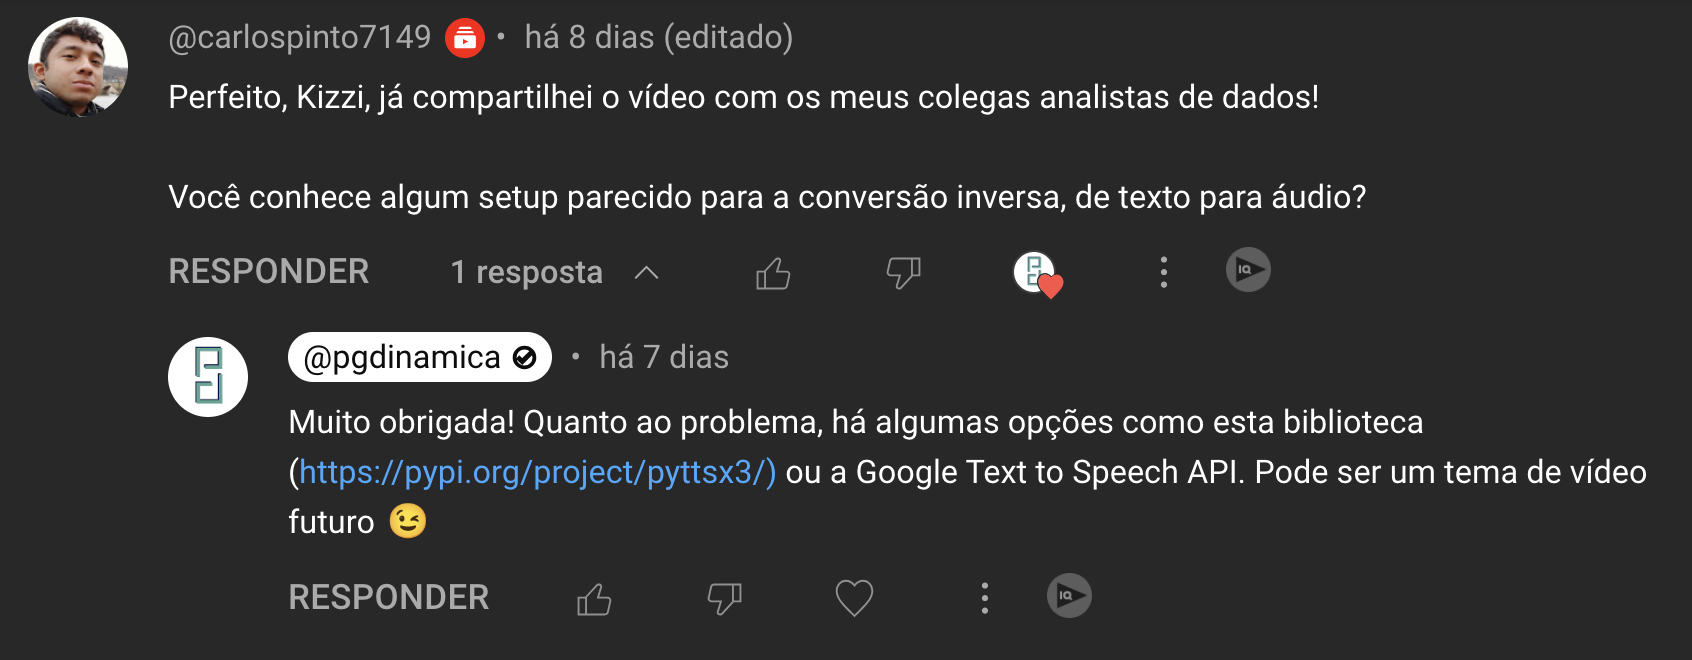

In [6]:
!pip install gTTS

In [7]:
from gtts import gTTS

In [11]:
#Ler texto do arquivo
with open(f'{1214}.txt', "r") as text_file:
    transcription = text_file.read()
#print(audio_transcription)

In [12]:
tts = gTTS(transcription, lang ="pt" ,tld="com.br")
gtts_audio_file = f'{Teste}-gtts.mp3'
tts.save(gtts_audio_file)

In [13]:
from IPython.display import Audio

In [14]:
Audio(gtts_audio_file)

Pacotes Python utilizados:

https://openai.com/research/whisper

https://pypi.org/project/openai-whisper/

https://pypi.org/project/yt-dlp/

https://pypi.org/project/gTTS/

https://gtts.readthedocs.io/en/latest/module.html#localized-accents
